Seed 1 - Number of Pareto front points: 100


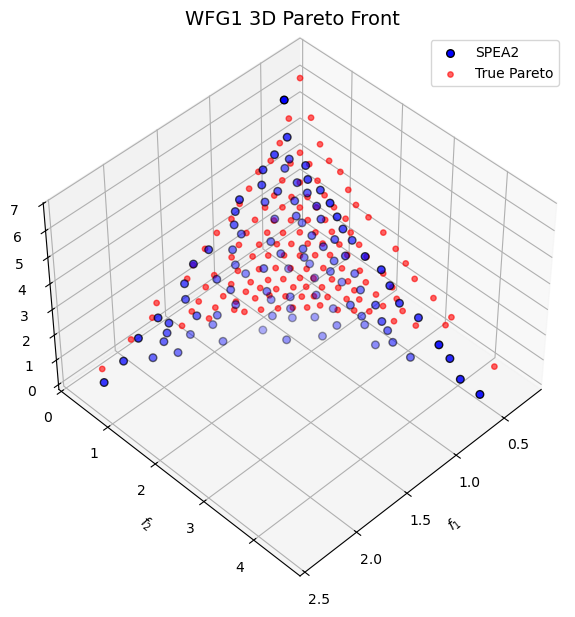

Seed 2 - Number of Pareto front points: 100


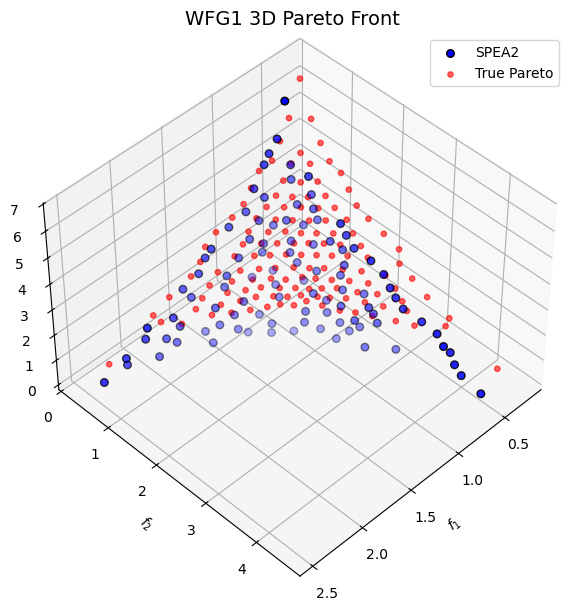

Seed 3 - Number of Pareto front points: 100


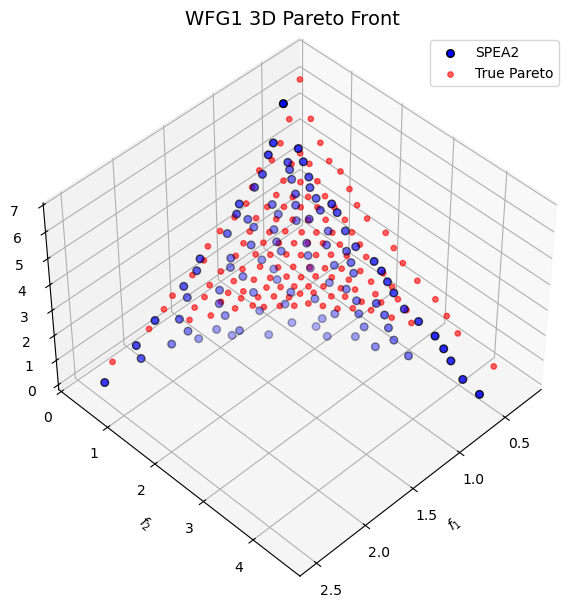

Seed 4 - Number of Pareto front points: 100


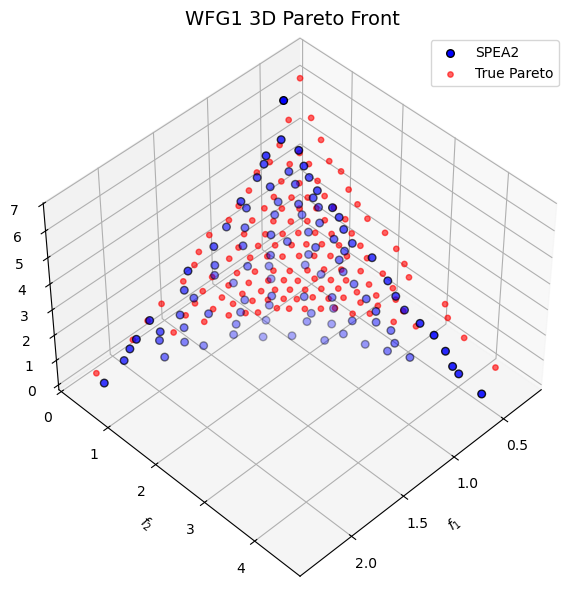

Seed 5 - Number of Pareto front points: 100


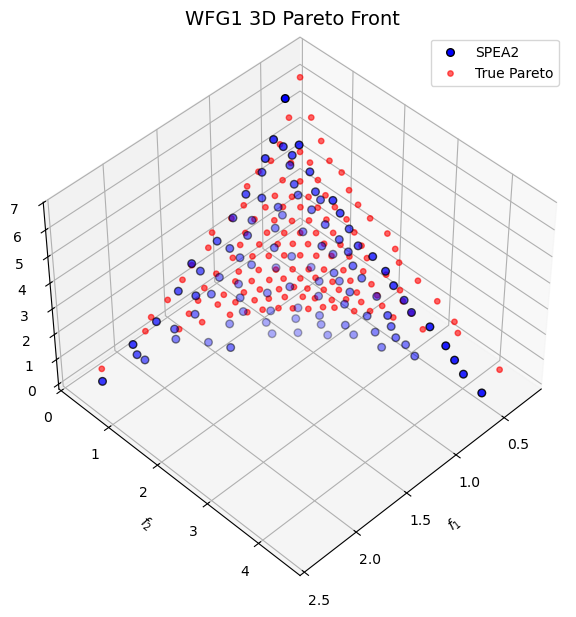

Seed 6 - Number of Pareto front points: 100


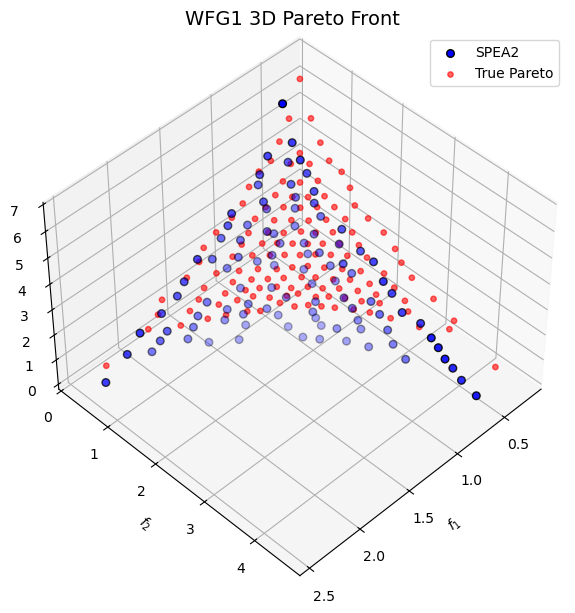

Seed 7 - Number of Pareto front points: 100


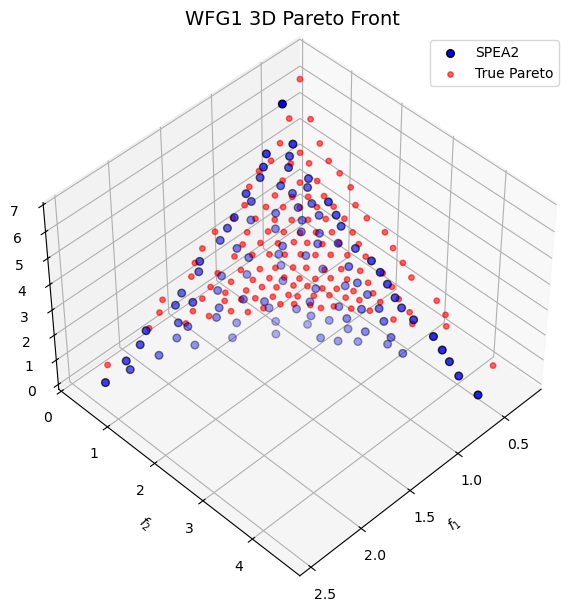

Seed 8 - Number of Pareto front points: 100


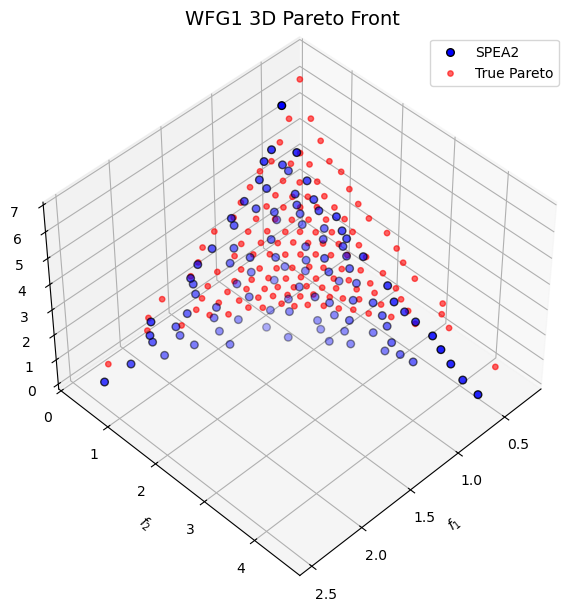

Seed 9 - Number of Pareto front points: 100


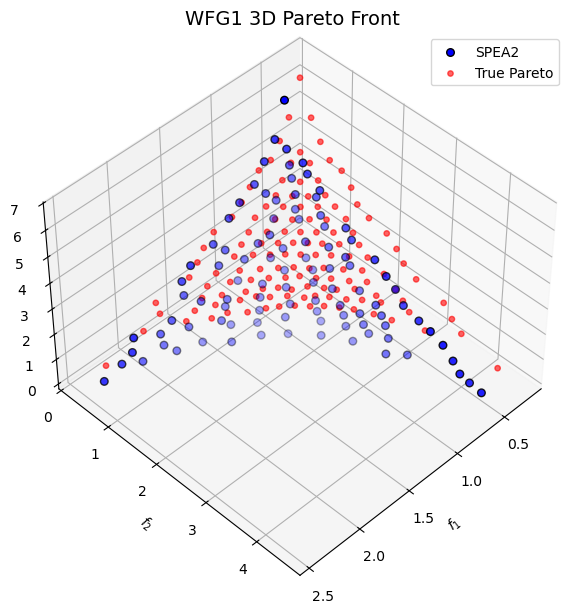

Seed 10 - Number of Pareto front points: 100


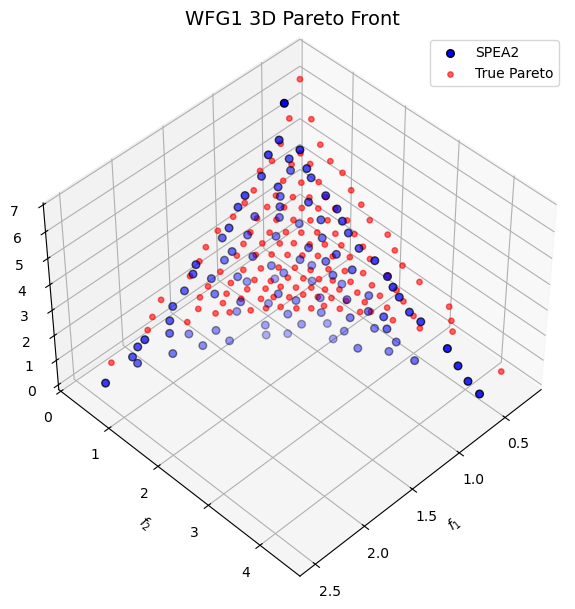

Seed 11 - Number of Pareto front points: 100


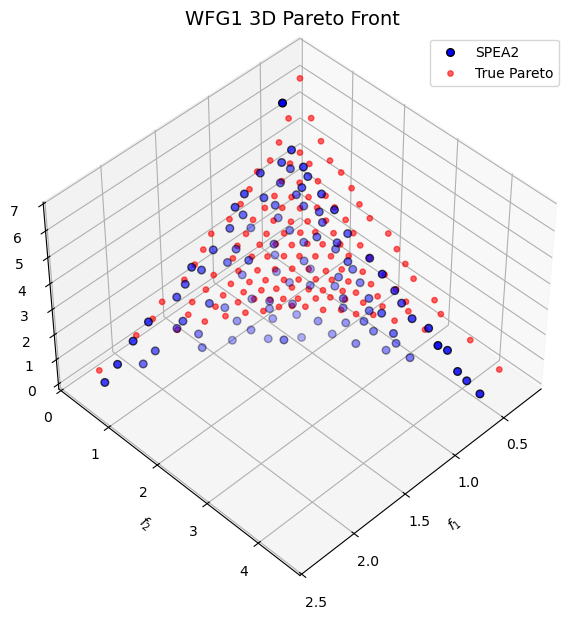

Seed 12 - Number of Pareto front points: 100


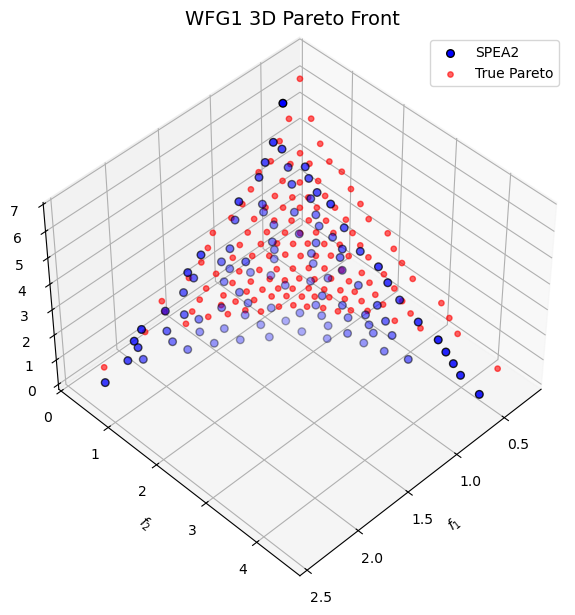

Seed 13 - Number of Pareto front points: 100


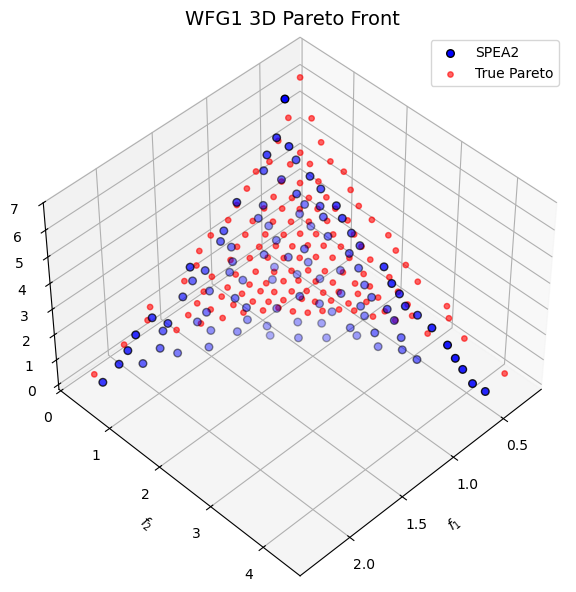

Seed 14 - Number of Pareto front points: 100


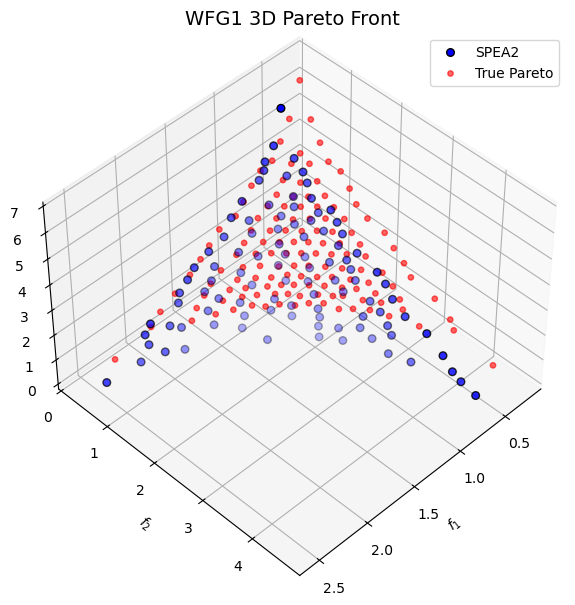

Seed 15 - Number of Pareto front points: 100


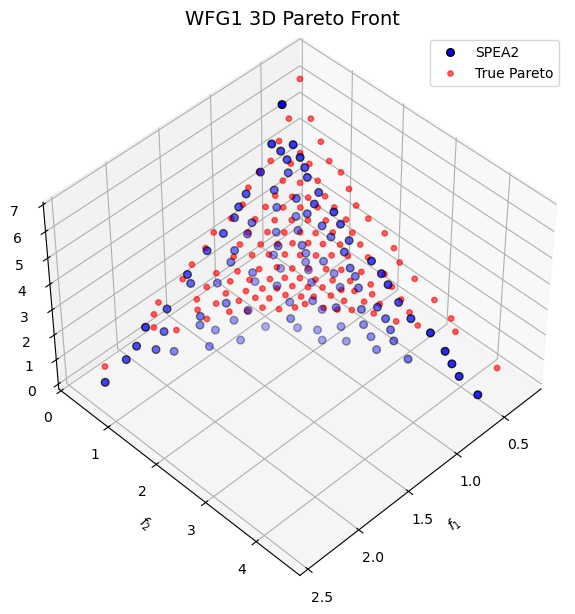

Seed 16 - Number of Pareto front points: 100


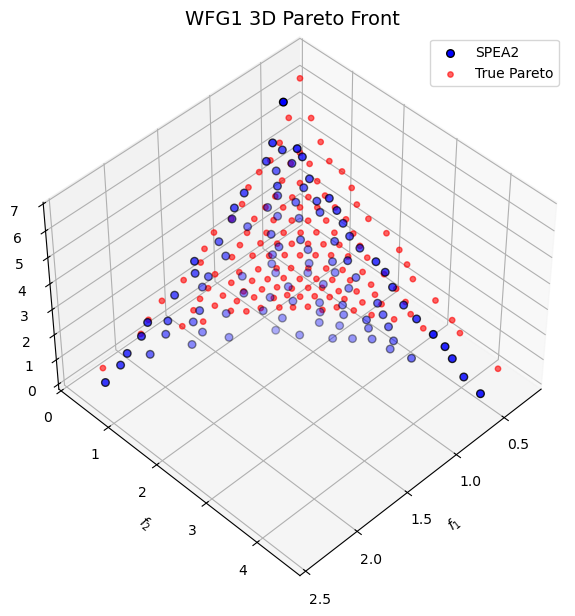

Seed 17 - Number of Pareto front points: 100


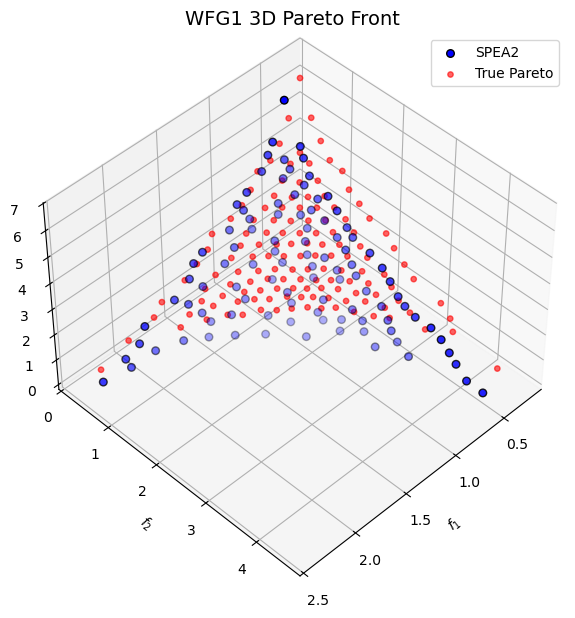

Seed 18 - Number of Pareto front points: 100


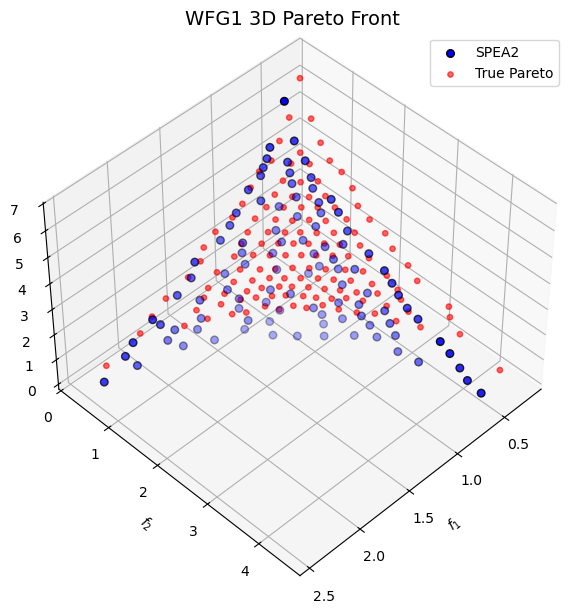

Seed 19 - Number of Pareto front points: 100


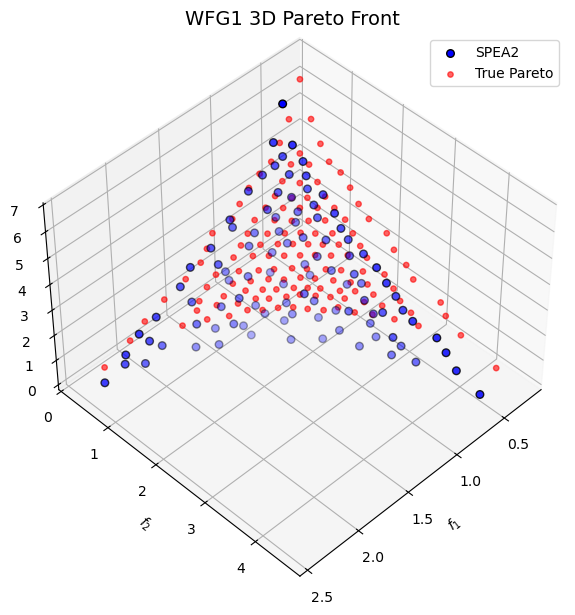

Seed 20 - Number of Pareto front points: 100


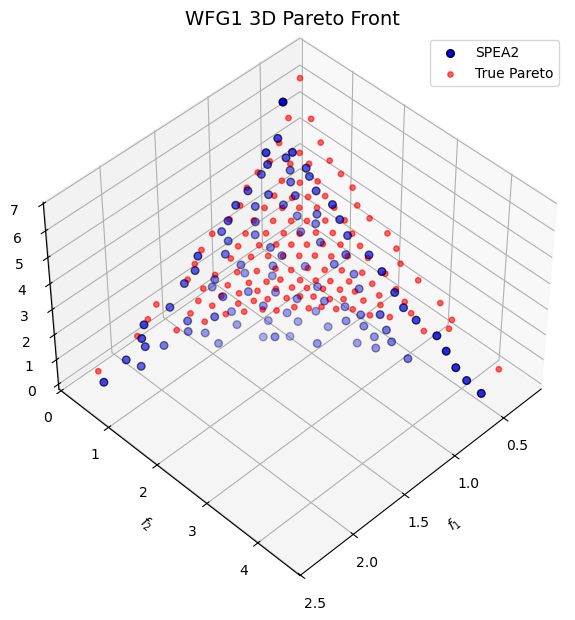

Seed 21 - Number of Pareto front points: 100


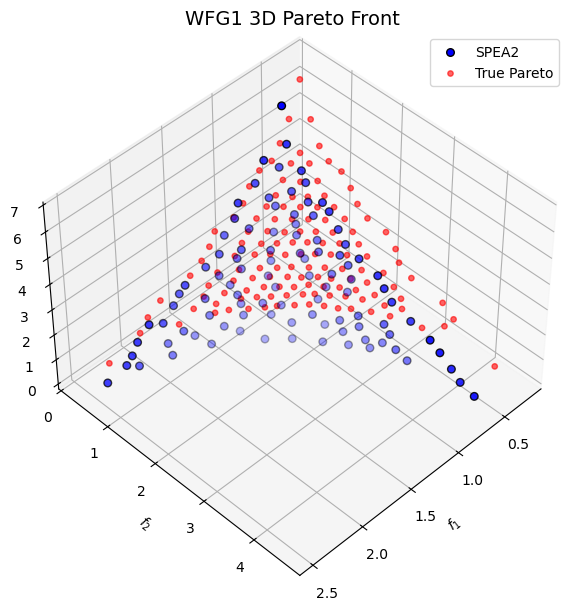

Seed 22 - Number of Pareto front points: 100


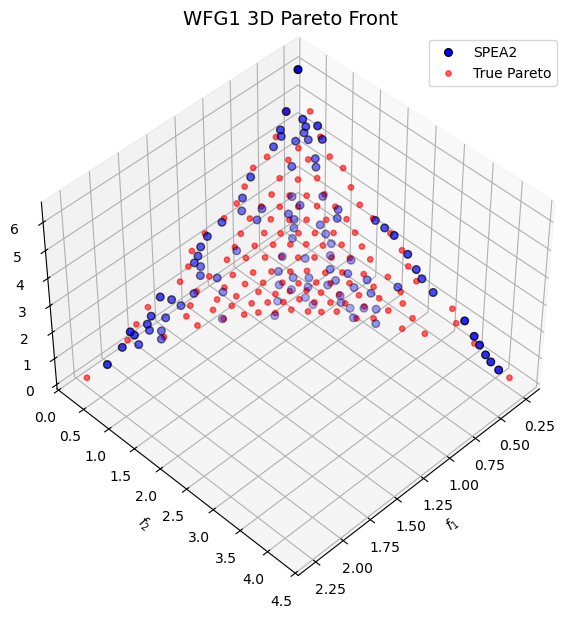

Seed 23 - Number of Pareto front points: 100


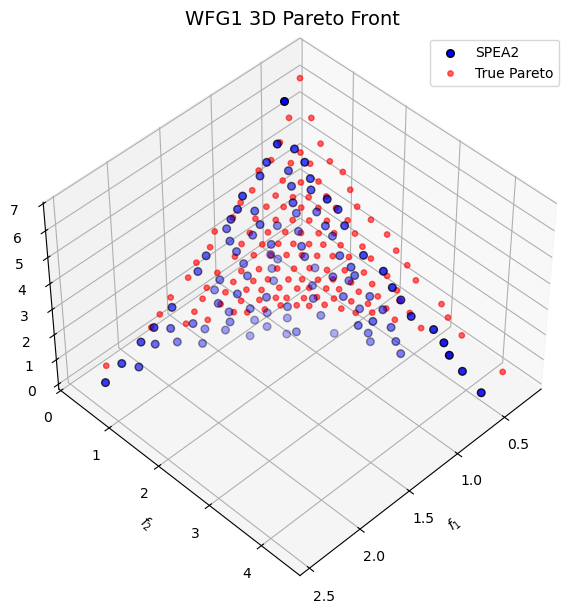

Seed 24 - Number of Pareto front points: 100


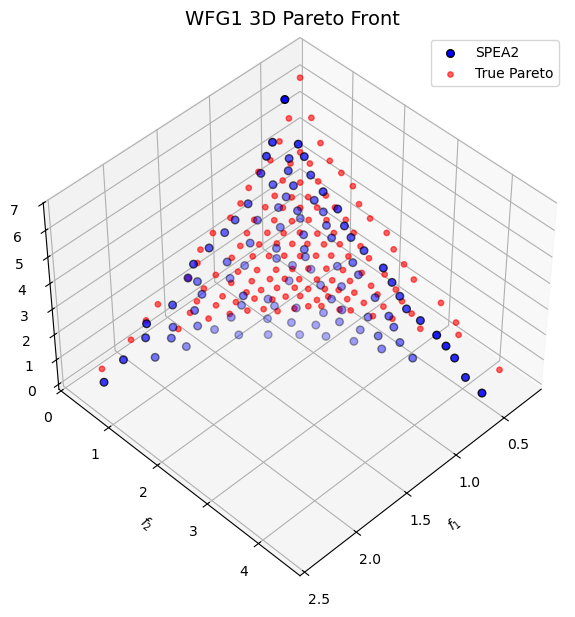

Seed 25 - Number of Pareto front points: 100


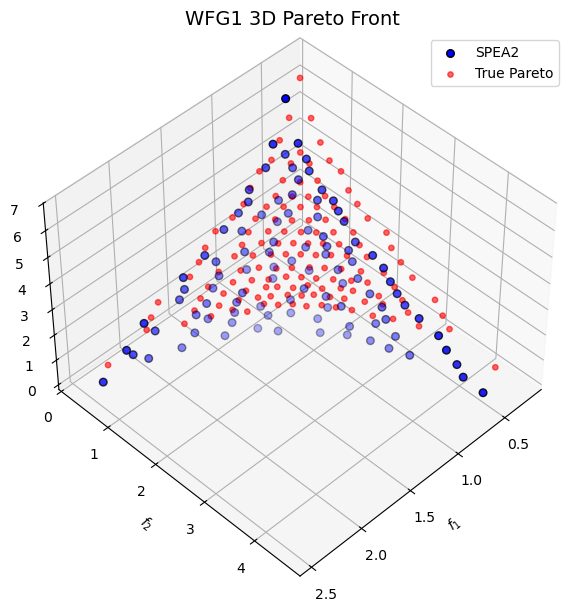

Seed 26 - Number of Pareto front points: 100


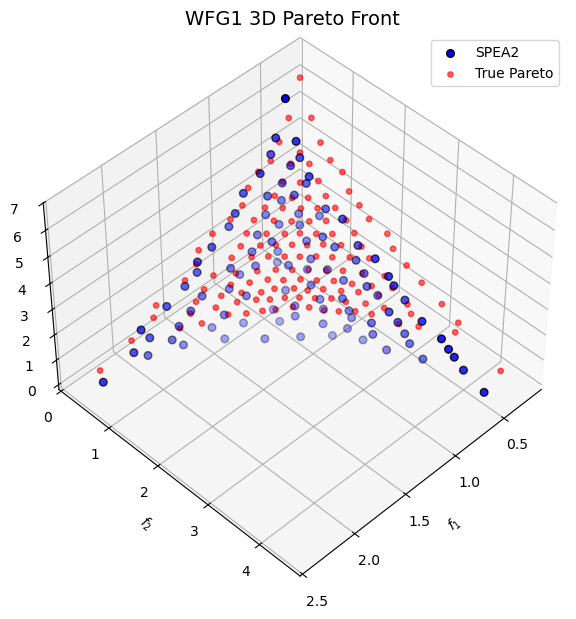

Seed 27 - Number of Pareto front points: 100


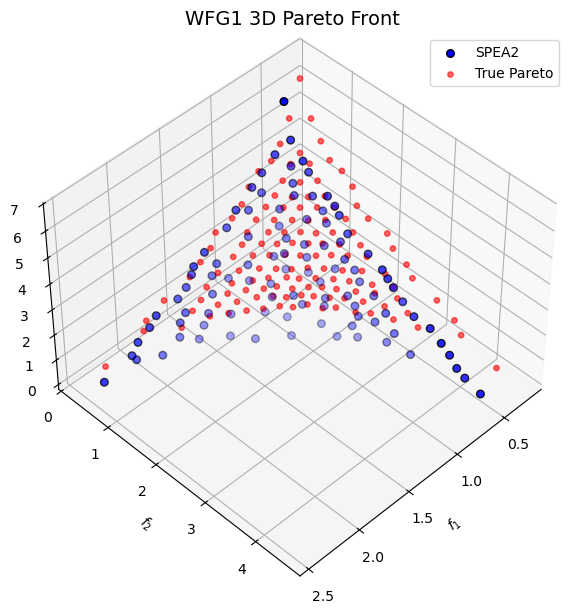

Seed 28 - Number of Pareto front points: 100


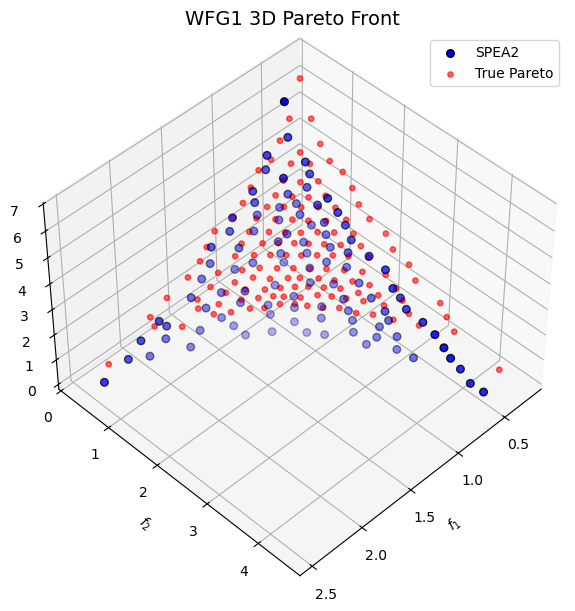

Seed 29 - Number of Pareto front points: 100


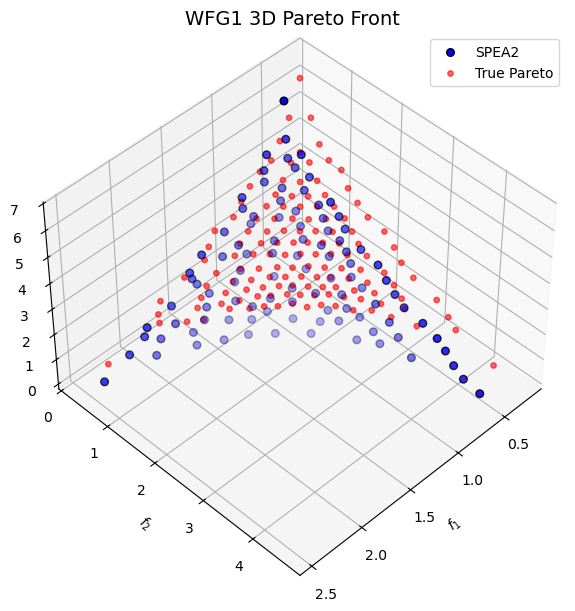

Seed 30 - Number of Pareto front points: 100


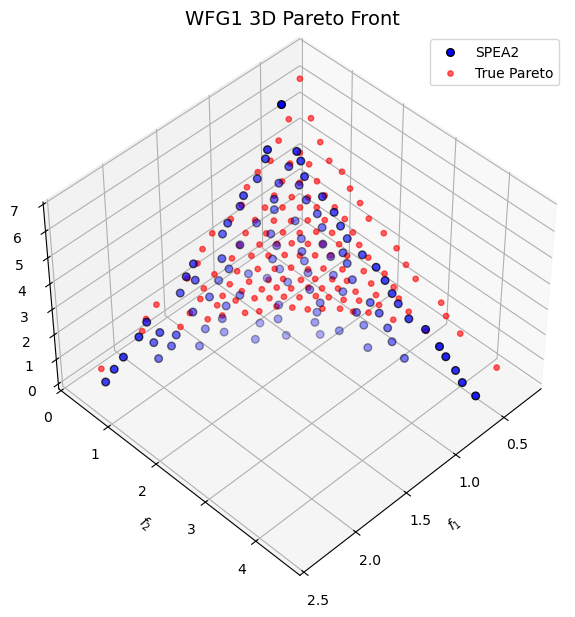

In [1]:
#SPEA2-PVOS-4C
#### Cell 0: Imports and Setup

# 1. Problem Selection and Configuration
#According to Table 2 in the Parallel Variation Operator Strategy: Equal‑Budget Parallel Crossover Ensembles for NSGA‑II
problem_name = "zdt1"
n_var = 30 # Custom number of decision variables 
n_obj = 2  # Custom number of objectives

# 2. Population Settings
# -----------------------
pop_size = 100
generations = 200
archive_size = None   # None -> use population size for the SPEA2 archive
# 3. Operator-specific parameters
#According to Table 1 in the Parallel Variation Operator Strategy: Equal‑Budget Parallel Crossover Ensembles for NSGA‑II
crossover_probability = 0.9
mutation_sigma = 0.5           
distribution_index_n_c = 15    # For simulated binary crossover
distribution_index_n_m = 20    # For polynomial mutation
blend_alpha = 0.5              # for blend crossover
swap_prob = 0.5                # For uniform crossover 


# 4. Select Crossover and Mutation Operators
# List all desired crossover operators to be applied in parallel.
selected_crossover_operator_names = [
    "simulated_binary_crossover_batch",
    "single_point_crossover_batch",
    "blend_crossover_batch",
    "uniform_crossover_batch"
    
]

selected_mutation_operator_name = "polynomial_mutation_batch"




# Cell 1:


import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
from IPython.display import display, clear_output
import time  
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
import random
from pymoo.problems import get_problem
from pymoo.operators.crossover.sbx import SBX
# --- Additional Metrics Imports (if not already imported) ---
from pymoo.indicators.gd import GD
from pymoo.indicators.gd_plus import GDPlus
from pymoo.indicators.igd_plus import IGDPlus
from pymoo.indicators.spacing import SpacingIndicator as Spacing
%matplotlib inline
plt.ion()  

# benchmarks.py
from pymoo.problems import get_problem as _get_problem

def _family(name: str) -> str:
    n = name.lower()
    if n.startswith("zdt"): return "zdt"
    if n.startswith("wfg"): return "wfg"
    if n.startswith("dtlz"): return "dtlz"
    if n.startswith("c") and "dtlz" in n: return "cdtlz"  # e.g. c1dtlz1
    return "unknown"

def get_problem_dynamic(name: str, n_var: int | None = None, n_obj: int | None = None):
    """
    Robustly instantiate a Pymoo problem without you having to remember the exact signature.
    Tries the 'right' order per family, then falls back gracefully.
    """
    fam = _family(name)

    # preferred try-orders per family
    if fam in {"dtlz", "wfg"}:
        attempts = [
            lambda: _get_problem(name, n_var=n_var, n_obj=n_obj),
            lambda: _get_problem(name, n_var=n_var),
            lambda: _get_problem(name),
        ]
    elif fam == "zdt":
        attempts = [
            lambda: _get_problem(name, n_var=n_var),
            lambda: _get_problem(name),
        ]
    elif fam == "cdtlz":
        attempts = [
            lambda: _get_problem(name),  # many constrained DTLZ variants expose fixed dims
            lambda: _get_problem(name, n_var=n_var, n_obj=n_obj),
            lambda: _get_problem(name, n_var=n_var),
        ]
    else:
        attempts = [
            lambda: _get_problem(name, n_var=n_var, n_obj=n_obj),
            lambda: _get_problem(name, n_var=n_var),
            lambda: _get_problem(name),
        ]

    last_err = None
    for a in attempts:
        try:
            return a()
        except TypeError as e:    # signature mismatch
            last_err = e
        except Exception as e:    # other errors (invalid name, etc.)
            last_err = e

    raise RuntimeError(
        f"Could not instantiate '{name}' with n_var={n_var}, n_obj={n_obj}. Last error: {last_err}"
    )







# Cell 2: Configuration Parameters

# =============================================================================
#                            PVOS-4C Configuration
# =============================================================================



problem = get_problem_dynamic(problem_name, n_var=n_var, n_obj=n_obj)


D = problem.n_var        
M = problem.n_obj        
min_values = problem.xl  
max_values = problem.xu  
mutation_probability = 1/D 







# --- Dictionary Mapping for Metrics ---
metrics_dict = {
    "hv": lambda front, ref_point: HV(ref_point=ref_point).do(front) if ref_point is not None else None,
    "igd": lambda front, true_front: IGD(true_front).do(front),
    "gd": lambda front, true_front: GD(true_front).do(front),
    "gd_plus": lambda front, true_front: GDPlus(true_front).do(front),
    "igd_plus": lambda front, true_front: IGDPlus(true_front).do(front),
    "spacing": lambda front: np.nan if front.shape[0] < 2 else Spacing().do(front)

}



#  Random Seed for Reproducibility
# -----------------------------------
random_seed = 1 


#  Visualization Settings
# --------------------------
plot_interval = 1
display_intermediate = False


#  Metrics Computation Control
compute_metrics_each_gen = True    # Set True to compute metrics every generation
default_metrics_interval = 1    # Interval to use if not computing each generation




# main.ipynb - Cell 3
import numpy as np


def initial_population(population_size, min_values, max_values, problem):
    # Generate random decision variables within bounds
    rand_matrix = np.random.rand(population_size, problem.n_var)
    decision_vars = min_values + rand_matrix * (max_values - min_values)
    
    if hasattr(problem, 'n_constr') and problem.n_constr > 0:
        # Evaluate and get both objectives and constraints
        eval_result = problem.evaluate(decision_vars, return_values_of=['F', 'G'])
        F = eval_result[0]
        G = eval_result[1]
        # Compute aggregated constraint violation (CV) for each individual
        CV = np.sum(np.maximum(G, 0), axis=1, keepdims=True)
        if F.ndim == 3 and F.shape[1] == 1:
            F = np.squeeze(F, axis=1)
        return np.hstack([decision_vars, F, CV])
    else:
        eval_result = problem.evaluate(decision_vars)
        if isinstance(eval_result, tuple):
            F = eval_result[0]
        else:
            F = eval_result
        if F.ndim == 3 and F.shape[1] == 1:
            F = np.squeeze(F, axis=1)
        return np.hstack([decision_vars, F])



# =============================================================================
# SPEA2-SPECIFIC SELECTION HELPERS
# =============================================================================


def _extract_objectives_and_cv(population, num_objectives, num_constraints=0):
    """
    Extract objective values and the aggregated constraint violation from the flat
    population array used throughout this notebook.
    """
    if num_constraints > 0:
        n_dec = population.shape[1] - num_objectives - num_constraints
        F = population[:, n_dec:n_dec + num_objectives]
        CV = population[:, -num_constraints:].reshape(population.shape[0], num_constraints)[:, 0]
    else:
        F = population[:, -num_objectives:]
        CV = np.zeros(population.shape[0], dtype=float)

    return F.astype(float, copy=False), CV.astype(float, copy=False)



def _pairwise_euclidean_distances(F):
    """
    Dense Euclidean distance matrix in objective space.
    """
    diff = F[:, None, :] - F[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2))



def spea2_dominance_matrix(population, num_objectives, num_constraints=0):
    """
    Pairwise dominance matrix used by SPEA2.

    dominates[i, j] == True  means individual i dominates individual j.

    For constrained problems we keep the same feasibility-first dominance logic
    that your NSGA-II code already used:
      - feasible dominates infeasible
      - among feasible: Pareto dominance in objective space
      - among infeasible: lower aggregated CV dominates higher CV
    """
    F, CV = _extract_objectives_and_cv(population, num_objectives, num_constraints)
    n = population.shape[0]

    ObjA = F[:, None, :]
    ObjB = F[None, :, :]
    obj_dom = (ObjA <= ObjB).all(axis=2) & (ObjA < ObjB).any(axis=2)

    if num_constraints > 0:
        feasible = CV <= 0.0
        cv_i = CV[:, None]
        cv_j = CV[None, :]
        cv_dom = cv_i < cv_j

        dominates = (
            (feasible[:, None] & ~feasible[None, :]) |
            (feasible[:, None] & feasible[None, :] & obj_dom) |
            (~feasible[:, None] & ~feasible[None, :] & cv_dom)
        )
    else:
        dominates = obj_dom

    np.fill_diagonal(dominates, False)
    return dominates



def get_nondominated_indices(population, num_objectives, num_constraints=0):
    """
    Return indices of the non-dominated solutions under the same dominance rules
    used by the SPEA2 fitness assignment.
    """
    dominates = spea2_dominance_matrix(population, num_objectives, num_constraints)
    dominated = dominates.any(axis=0)
    return np.where(~dominated)[0]



def spea2_fitness_assignment(population, num_objectives, num_constraints=0):
    """
    ---------------------------------------------------------------------------
    SPEA2 Fitness Assignment
    ---------------------------------------------------------------------------
    Implements:
      S(i): strength = number of solutions dominated by i
      R(i): raw fitness = sum of strengths of all dominators of i
      D(i): density = 1 / (sigma_k(i) + 2)
      F(i): final fitness = R(i) + D(i)   (lower is better)

    Here k = floor(sqrt(N)), and sigma_k is the Euclidean distance to the k-th
    nearest neighbor in objective space.
    """
    n = population.shape[0]
    F_obj, CV = _extract_objectives_and_cv(population, num_objectives, num_constraints)
    dominates = spea2_dominance_matrix(population, num_objectives, num_constraints)

    # Strength S(i): number of solutions i dominates
    S = dominates.sum(axis=1).astype(float, copy=False)

    # Raw fitness R(i): sum of strengths of all solutions that dominate i
    R = (dominates.T * S[None, :]).sum(axis=1)

    if n <= 1:
        k = 0
        sigma_k = np.full(n, np.inf)
        D_density = np.zeros(n, dtype=float)
        distances = np.full((n, n), np.inf, dtype=float)
    else:
        # Density estimation in objective space
        distances = _pairwise_euclidean_distances(F_obj)
        np.fill_diagonal(distances, np.inf)

        k = int(np.floor(np.sqrt(n)))
        k = max(1, min(k, n - 1))

        sorted_distances = np.sort(distances, axis=1)
        sigma_k = sorted_distances[:, k - 1]
        D_density = 1.0 / (sigma_k + 2.0)

    fitness = R + D_density

    return {
        "F_obj": F_obj,
        "CV": CV,
        "dominates": dominates,
        "strength": S,
        "raw_fitness": R,
        "density": D_density,
        "fitness": fitness,
        "distances": distances,
        "sigma_k": sigma_k,
        "k": k,
        # In SPEA2, F(i) < 1 is equivalent to raw fitness R(i) == 0
        "nondominated_indices": np.where(fitness < 1.0)[0]
    }



def spea2_truncation(objective_values, candidate_indices, target_size):
    """
    ---------------------------------------------------------------------------
    SPEA2 Truncation Operator
    ---------------------------------------------------------------------------
    If the archive overflows, iteratively remove the individual with the
    smallest distance to its nearest neighbor. Ties are broken lexicographically
    using the 2nd nearest, 3rd nearest, and so on, exactly as requested.
    """
    survivors = list(candidate_indices)

    while len(survivors) > target_size:
        local_F = objective_values[survivors]
        local_distances = _pairwise_euclidean_distances(local_F)
        np.fill_diagonal(local_distances, np.inf)
        sorted_local_distances = np.sort(local_distances, axis=1)

        # Lexicographic tie-break on nearest, 2nd nearest, 3rd nearest, ...
        remove_local = min(
            range(len(survivors)),
            key=lambda i: tuple(sorted_local_distances[i])
        )
        del survivors[remove_local]

    return np.asarray(survivors, dtype=int)



def spea2_update_archive(population, archive, archive_size, num_objectives, num_constraints=0):
    """
    ---------------------------------------------------------------------------
    SPEA2 External Archive Update
    ---------------------------------------------------------------------------
    1) Combine current population and current archive into a union.
    2) Compute SPEA2 fitness on the union.
    3) Copy all non-dominated individuals (F(i) < 1) into the new archive.
    4) If archive overflows -> truncation.
    5) If archive underflows -> fill with best dominated individuals by fitness.
    """
    if archive is None or archive.shape[0] == 0:
        union = population.copy()
    else:
        union = np.vstack([population, archive])

    fit = spea2_fitness_assignment(union, num_objectives, num_constraints)

    archive_indices = fit["nondominated_indices"].tolist()

    if len(archive_indices) > archive_size:
        archive_indices = spea2_truncation(
            fit["F_obj"],
            archive_indices,
            archive_size
        ).tolist()

    elif len(archive_indices) < archive_size:
        already_selected = set(archive_indices)
        dominated_indices = np.array(
            [i for i in range(len(union)) if i not in already_selected],
            dtype=int
        )

        if dominated_indices.size > 0:
            dominated_sorted = dominated_indices[
                np.argsort(fit["fitness"][dominated_indices], kind="mergesort")
            ]
            archive_indices.extend(
                dominated_sorted[:archive_size - len(archive_indices)].tolist()
            )

    archive_indices = np.asarray(archive_indices, dtype=int)
    new_archive = union[archive_indices].copy()

    return new_archive, {
        "union": union,
        "archive_indices": archive_indices,
        "archive_fitness": fit["fitness"][archive_indices],
        "archive_raw_fitness": fit["raw_fitness"][archive_indices],
        "archive_density": fit["density"][archive_indices],
        "archive_strength": fit["strength"][archive_indices],
        "archive_nondominated_mask": fit["fitness"][archive_indices] < 1.0,
        "fitness_info": fit,
    }



def select_parents_batch(archive, archive_fitness, population_size):
    """
    ---------------------------------------------------------------------------
    SPEA2 Mating Selection
    ---------------------------------------------------------------------------
    Binary tournament on SPEA2 fitness F(i), drawing parents exclusively from
    the current archive. Lower fitness is better.
    """
    n_archive = archive.shape[0]

    if n_archive == 0:
        raise ValueError("SPEA2 archive is empty. Parent selection cannot proceed.")

    if n_archive == 1:
        zeros = np.zeros(population_size, dtype=int)
        return zeros, zeros

    def _binary_tournament_once():
        pair_idx = np.random.randint(0, n_archive, size=(population_size, 2))
        f1 = archive_fitness[pair_idx[:, 0]]
        f2 = archive_fitness[pair_idx[:, 1]]

        tie = np.isclose(f1, f2, rtol=0.0, atol=1e-12)
        choose_first = (f1 < f2) | (tie & (np.random.rand(population_size) < 0.5))
        return np.where(choose_first, pair_idx[:, 0], pair_idx[:, 1])

    selected_parents1 = _binary_tournament_once()
    selected_parents2 = _binary_tournament_once()

    return selected_parents1, selected_parents2





#cell 4




import numpy as np

def _sbx_core_batch(parents_dec_1, parents_dec_2, xl, xu,
                    eta_arr, prob_var_arr, prob_bin_arr,
                    eps=1e-14):
    """
    Core SBX operator matching pymoo.cross_sbx, but using
    parents_dec_1, parents_dec_2 instead of X.

    parents_dec_1, parents_dec_2 : (N, D)
    eta_arr, prob_var_arr, prob_bin_arr : (N, 1)

    Returns:
        Q : (2, N, D)  # two children per mating
    """
    parents_dec_1 = np.asarray(parents_dec_1, dtype=float)
    parents_dec_2 = np.asarray(parents_dec_2, dtype=float)
    xl = np.asarray(xl, dtype=float)
    xu = np.asarray(xu, dtype=float)

    N, D = parents_dec_1.shape
    X = np.stack([parents_dec_1, parents_dec_2], axis=0)  # (2, N, D)

    # probability of crossover for each variable
    prob_var_2d = np.repeat(prob_var_arr, D, axis=1)      # (N, D)
    cross = np.random.rand(N, D) < prob_var_2d

    # when solutions are too close -> do not apply sbx crossover
    too_close = np.abs(X[0] - X[1]) <= eps
    cross[too_close] = False

    # disable crossover when lower and upper bound are identical
    cross[:, xl == xu] = False

    # if no variable crosses at all, just clamp bounds and return
    if not np.any(cross):
        Q = X.copy()
        Q[0] = np.clip(Q[0], xl, xu)
        Q[1] = np.clip(Q[1], xl, xu)
        return Q

    # flatten the crossed positions
    p1 = X[0][cross]  # (n_cross,)
    p2 = X[1][cross]

    # orientation: y1 = smaller, y2 = larger
    sm = p1 < p2
    y1 = np.where(sm, p1, p2)
    y2 = np.where(sm, p2, p1)

    # bounds repeated and masked
    _xl = np.repeat(xl[None, :], N, axis=0)[cross]
    _xu = np.repeat(xu[None, :], N, axis=0)[cross]

    # eta, prob_bin expanded to (N, D) then masked
    eta_flat = np.repeat(eta_arr, D, axis=1)[cross]       # (n_cross,)
    prob_bin_flat = np.repeat(prob_bin_arr, D, axis=1)[cross]

    # shared random for both c1 and c2 (same as pymoo)
    rand = np.random.rand(len(eta_flat))

    def calc_betaq(beta):
        alpha = 2.0 - np.power(beta, -(eta_flat + 1.0))
        mask = rand <= (1.0 / alpha)
        mask_not = ~mask

        betaq = np.zeros_like(beta)
        if np.any(mask):
            betaq[mask] = np.power(rand[mask] * alpha[mask],
                                   1.0 / (eta_flat[mask] + 1.0))
        if np.any(mask_not):
            betaq[mask_not] = np.power(
                1.0 / (2.0 - rand[mask_not] * alpha[mask_not]),
                1.0 / (eta_flat[mask_not] + 1.0)
            )
        return betaq

    # difference between parents
    delta = (y2 - y1)

    # c1
    beta = 1.0 + (2.0 * (y1 - _xl) / delta)
    betaq = calc_betaq(beta)
    c1 = 0.5 * ((y1 + y2) - betaq * delta)

    # c2
    beta = 1.0 + (2.0 * (_xu - y2) / delta)
    betaq = calc_betaq(beta)
    c2 = 0.5 * ((y1 + y2) + betaq * delta)

    # children based on parent orientation
    child1 = np.where(sm, c1, c2)  # child aligned with parent 1
    child2 = np.where(sm, c2, c1)  # child aligned with parent 2

    # exchange children with probability prob_bin_flat and orientation
    b = np.bitwise_xor(
        np.random.rand(len(prob_bin_flat)) < prob_bin_flat,
        X[0][cross] > X[1][cross]
    )
    child1_final = np.where(b, child2, child1)
    child2_final = np.where(b, child1, child2)

    # assemble Q
    Q = X.copy()
    Q[0][cross] = child1_final
    Q[1][cross] = child2_final

    # clamp to bounds
    Q[0] = np.clip(Q[0], xl, xu)
    Q[1] = np.clip(Q[1], xl, xu)
    return Q


def simulated_binary_crossover_batch(parents_dec_1, parents_dec_2,
                                     prob, eta, min_values, max_values,
                                     n_offsprings=1,
                                     prob_exch=1.0,
                                     prob_bin=0.5,
                                     eps=1e-14):
    """
    Simulated Binary Crossover (SBX) matching pymoo.SBX(prob=..., eta=..., n_offsprings=...)

    Parameters
    ----------
    parents_dec_1 : (N, D)
    parents_dec_2 : (N, D)
    prob          : float
        Per-variable crossover probability (SBX 'prob' / 'prob_var').
    eta           : float
        Distribution index.
    min_values    : (D,)  lower bounds (xl)
    max_values    : (D,)  upper bounds (xu)
    n_offsprings  : 1 or 2
    prob_exch     : float, default 1.0
        Exchange probability (SBX prob_exch).
    prob_bin      : float, default 0.5
        Per-gene child swap probability (SBX prob_bin).
    eps           : float
        Threshold for "too close" parents.

    Returns
    -------
    offspring_dec :
        if n_offsprings == 1 : shape (N, D)
        if n_offsprings == 2 : shape (2*N, D)  [first N rows child1, next N rows child2]
    """
    parents_dec_1 = np.asarray(parents_dec_1, dtype=float)
    parents_dec_2 = np.asarray(parents_dec_2, dtype=float)
    min_values = np.asarray(min_values, dtype=float)
    max_values = np.asarray(max_values, dtype=float)

    N, D = parents_dec_1.shape

    # parameter arrays (N, 1) – same idea as pymoo's get(...)
    eta_arr = np.full((N, 1), eta, dtype=float)
    prob_var_arr = np.full((N, 1), prob, dtype=float)
    prob_exch_arr = np.full((N, 1), prob_exch, dtype=float)
    prob_bin_arr = np.full((N, 1), prob_bin, dtype=float)

    # apply prob_exch: zero out prob_bin if no exchange for that mating
    rand = np.random.rand(N, 1)
    prob_bin_arr[rand > prob_exch_arr] = 0.0

    # core SBX – returns two children per mating: Q shape (2, N, D)
    Q = _sbx_core_batch(parents_dec_1, parents_dec_2,
                        min_values, max_values,
                        eta_arr, prob_var_arr, prob_bin_arr,
                        eps=eps)

    if n_offsprings == 1:
        # randomly pick one of the two offspring per mating (same as SBX.n_offsprings=2)
        child = Q[0].copy()           # (N, D)
        pick_second = np.random.rand(N) < 0.5
        child[pick_second] = Q[1, pick_second]
        return child

    elif n_offsprings == 2:
        # stack to (2*N, D): [child1_0..child1_{N-1}, child2_0..child2_{N-1}]
        return Q.reshape(2 * N, D)

    else:
        raise ValueError("n_offsprings must be 1 or 2")





def single_point_crossover_batch(parents_dec_1, parents_dec_2, crossover_probability, min_values, max_values):
    """
    Perform single-point crossover on a batch of parent pairs.

    Parameters:
        parents_dec_1 (np.ndarray): Decision variables of parent 1, shape (N, D).
        parents_dec_2 (np.ndarray): Decision variables of parent 2, shape (N, D).
        crossover_probability (float): Probability of performing crossover on a parent pair.
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).

    Returns:
        
    """

    num_offspring, num_decision_variables = parents_dec_1.shape

    # Start with child1 as a copy of parent 1
    child1 = parents_dec_1.copy()

    # Decide which pairs will undergo crossover
    crossover_mask = np.random.rand(num_offspring) < crossover_probability

    # --- NEW: handle no-crossover pairs without bias ---
    no_cross_indices = np.where(~crossover_mask)[0]
    if no_cross_indices.size > 0:
        # For each no-crossover pair, flip a coin: 0 -> keep parent 1, 1 -> copy parent 2
        use_parent2 = np.random.rand(no_cross_indices.size) < 0.5
        idx_parent2 = no_cross_indices[use_parent2]
        # Overwrite those children with parent 2
        child1[idx_parent2, :] = parents_dec_2[idx_parent2, :]

    # --- Existing crossover logic for the pairs that do crossover ---
    crossover_indices = np.where(crossover_mask)[0]
    if crossover_indices.size > 0:
        # One crossover point per selected pair
        crossover_points = np.random.randint(1, num_decision_variables, size=crossover_indices.size)

        for idx, cp in zip(crossover_indices, crossover_points):
            # NEW: randomly choose orientation to remove positional bias
            if np.random.rand() < 0.5:
                # suffix from parent2
                child1[idx, cp:] = parents_dec_2[idx, cp:]
            else:
                # prefix from parent2
                child1[idx, :cp] = parents_dec_2[idx, :cp]

    # Clip to bounds and return
    child1 = np.clip(child1, min_values, max_values)
    return child1




import numpy as np

def blend_crossover_batch(parents_dec_1, parents_dec_2, crossover_probability, alpha_blend, min_values, max_values):

    N, D = parents_dec_1.shape

    child1 = parents_dec_1.copy()

    do_cross = np.random.rand(N) < crossover_probability

    # Handle pairs that do NOT crossover without bias
    no_cross_idx = np.where(~do_cross)[0]
    if no_cross_idx.size > 0:
        use_parent2 = np.random.rand(no_cross_idx.size) < 0.5
        idx_parent2 = no_cross_idx[use_parent2]
        child1[idx_parent2, :] = parents_dec_2[idx_parent2, :]

    cross_idx = np.where(do_cross)[0]
    if cross_idx.size > 0:
        p1 = parents_dec_1[cross_idx, :]
        p2 = parents_dec_2[cross_idx, :]

        y1 = np.minimum(p1, p2)
        y2 = np.maximum(p1, p2)
        d = y2 - y1

        # Full extended range — NO clamping to bounds here
        lower_bound = y1 - alpha_blend * d
        upper_bound = y2 + alpha_blend * d

        # Sample uniformly in the extended range
        rand1 = np.random.rand(p1.shape[0], D)
        c1 = lower_bound + rand1 * (upper_bound - lower_bound)

        child1[cross_idx, :] = c1

    # Clip AFTER sampling — this creates the boundary bias that helps ZDT convergence
    child1 = np.clip(child1, min_values, max_values)
    return child1

import numpy as np

def uniform_crossover_batch(parents_dec_1, parents_dec_2, crossover_probability,  min_values, max_values, swap_prob=swap_prob):
    """
    Perform Uniform Crossover on a batch of parent pairs.

    Parameters:
        parents_dec_1 (np.ndarray): Decision variables of parent 1, shape (N, D).
        parents_dec_2 (np.ndarray): Decision variables of parent 2, shape (N, D).
        crossover_probability (float): Probability of performing crossover on each parent pair.
        swap_prob (float, optional): Probability of swapping each gene. Defaults to 0.5.
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).

    Returns:
        tuple: Two arrays containing offspring decision variables, each of shape (N, D).
    """
    # Determine the number of parent pairs (N) and number of decision variables (D).
    N, D = parents_dec_1.shape
    p_c = crossover_probability

    # Initialize offspring arrays as copies of the parent decision variables.
    child1 = parents_dec_1.copy()
    

    # Determine which parent pairs will undergo crossover based on probability.
    do_cross = np.random.rand(N) < p_c

    # Handle pairs that do NOT crossover without bias:
    # for those indices, randomly choose between parent 1 and parent 2.
    no_cross_indices = np.where(~do_cross)[0]
    if no_cross_indices.size > 0:
        # Flip a coin for each no-crossover pair:
        # True -> use parent 2, False -> keep parent 1.
        use_parent2 = np.random.rand(no_cross_indices.size) < 0.5
        idx_parent2 = no_cross_indices[use_parent2]
        child1[idx_parent2, :] = parents_dec_2[idx_parent2, :]

    # If no pairs are selected for crossover, we are done.
    if not np.any(do_cross):
        child1 = np.clip(child1, min_values, max_values)
        return child1

    # Extract the parent pairs selected for crossover.
    p1 = parents_dec_1[do_cross, :]
    p2 = parents_dec_2[do_cross, :]

    # Generate a mask for each gene indicating whether to swap based on swap_prob.
    swap_mask = np.random.rand(p1.shape[0], D) < swap_prob

    # Create copies to hold the offspring genes.
    offspring1 = p1.copy()

    # Perform the swap where the mask is True.
    offspring1[swap_mask] = p2[swap_mask]

    # Assign the offspring genes back to the full child array.
    child1[do_cross, :] = offspring1

    # Ensure offspring values are within the specified bounds.
    child1 = np.clip(child1, min_values, max_values)

    # Return the generated offspring decision variables.
    return child1





def polynomial_mutation_batch(offspring_dec, mutation_probability, distribution_index_n_m,
                              min_values, max_values, at_least_once=False):
    """
    Perform Polynomial Mutation on a batch of offspring decision variables.

    This operator follows the conventional scheme (as in pymoo) and
    applies a mutation to each gene with a given probability.
    
    Parameters:
        offspring_dec (np.ndarray): Offspring decision variables, shape (N, D).
        mutation_probability (float): Mutation probability per gene.
        distribution_index_n_m (float): Mutation distribution index (η₍m₎).
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).
        at_least_once (bool): If True, ensure that at least one gene per individual is mutated.
        
    Returns:
        np.ndarray: Mutated offspring decision variables, shape (N, D).
    """
    N, D = offspring_dec.shape
    p_m = mutation_probability
    eta_m = distribution_index_n_m

    # Create a gene-wise mutation mask.
    mutation_mask = np.random.rand(N, D) < p_m
    # Do not allow mutation where lower and upper bounds are identical.
    mutation_mask[:, (min_values == max_values)] = False

    # If at_least_once is True, force at least one mutation per individual (if possible).
    if at_least_once:
        for i in range(N):
            if not np.any(mutation_mask[i]):
                # Identify genes that are allowed to be mutated.
                allowed = np.where(min_values != max_values)[0]
                if allowed.size > 0:
                    j = np.random.choice(allowed)
                    mutation_mask[i, j] = True

    # Convert offspring_dec to float for mutation computations.
    x = offspring_dec.astype(float).copy()

    # Compute the range for each decision variable.
    range_ = max_values - min_values

    # Compute normalized distances to the bounds.
    delta1 = (x - min_values) / (range_ + 1e-14)
    delta2 = (max_values - x) / (range_ + 1e-14)

    # Generate random numbers for the mutation process.
    u = np.random.rand(N, D)

    # Initialize delta_q (the mutation step sizes).
    deltaq = np.zeros((N, D))

    # Mutation: apply the polynomial mutation formula only for genes marked for mutation.
    # Branch where u < 0.5:
    mask1 = mutation_mask & (u < 0.5)
    if np.any(mask1):
        tmp = 2 * u[mask1] + (1 - 2 * u[mask1]) * np.power(1 - delta1[mask1], (eta_m + 1))
        deltaq[mask1] = np.power(tmp, 1.0 / (eta_m + 1)) - 1.0

    # Branch where u >= 0.5:
    mask2 = mutation_mask & (u >= 0.5)
    if np.any(mask2):
        tmp = 2 * (1 - u[mask2]) + 2 * (u[mask2] - 0.5) * np.power(1 - delta2[mask2], (eta_m + 1))
        deltaq[mask2] = 1.0 - np.power(tmp, 1.0 / (eta_m + 1))

    # Apply the mutation step.
    x = x + deltaq * range_
    # Ensure the mutated values are within the bounds.
    x = np.clip(x, min_values, max_values)

    return x


def gaussian_mutation_batch(offspring_dec, mutation_probability, sigma, min_values, max_values):
    """
    Perform Gaussian mutation on a batch of offspring decision variables.
    """
    # Determine population size and number of decision variables
    num_offspring, num_decision_variables = offspring_dec.shape
    
    # Create a mutation mask for each decision variable of each offspring
    mutation_mask = np.random.rand(num_offspring, num_decision_variables) < mutation_probability
    # Generate Gaussian noise where mutation is to be applied
    noise = np.random.normal(0, sigma, (num_offspring, num_decision_variables)) * mutation_mask
    # Apply mutation
    offspring_dec = offspring_dec + noise
    
    # Ensure mutated offspring values are within bounds
    offspring_dec = np.clip(offspring_dec, min_values, max_values)
    return offspring_dec



# Cell 5: Complete PVOS-4C Implementation with Pymoo Benchmarks
from joblib import Parallel, delayed
from pymoo.core.population import Population
from pymoo.core.individual import Individual

class _ArrayProblem:
    """Minimal stub so SBX sees n_var, xl, xu."""
    def __init__(self, xl, xu):
        self.xl, self.xu = xl, xu
        self.n_var = len(xl)

def run_nsga2(problem, population_size, generations,
              crossover_probability, mutation_probability,
              selected_crossover_operator_names,
              selected_mutation_operator_name,
              distribution_index_n_c, distribution_index_n_m,
              blend_alpha, swap_prob, mutation_sigma,
              random_seed, plot_interval, display_intermediate,
              metrics_interval, record_history=False):
    """
    Compatibility wrapper that preserves the original function name/signature,
    but replaces the NSGA-II selection internals with a full SPEA2 workflow.
    """
    # Get problem parameters from Pymoo object
    num_objectives = problem.n_obj
    num_decision_variables = problem.n_var
    min_values = problem.xl
    max_values = problem.xu
    num_constraints = 1 if (hasattr(problem, 'n_constr') and problem.n_constr > 0) else 0

    # objective slice in your population array [X | F] (or [X | F | CV])
    F_start = num_decision_variables
    F_end = num_decision_variables + num_objectives

    archive_size_eff = population_size if archive_size is None else int(archive_size)

    # Initialize operator map
    operator_map = {
        "simulated_binary_crossover_batch": simulated_binary_crossover_batch,
        "single_point_crossover_batch": single_point_crossover_batch,
        "polynomial_mutation_batch": polynomial_mutation_batch,
        "gaussian_mutation_batch": gaussian_mutation_batch,
        "blend_crossover_batch": blend_crossover_batch,
        "uniform_crossover_batch": uniform_crossover_batch
    }

    crossover_ops = [operator_map[co_name] for co_name in selected_crossover_operator_names]
    selected_mutation_operator = operator_map[selected_mutation_operator_name]

    # Set random seeds
    np.random.seed(random_seed)
    random.seed(random_seed)

    # Initialize population and archive
    population = initial_population(population_size, min_values, max_values, problem)
    population_operator_ids = np.array(["parent"] * population.shape[0], dtype=object)

    archive = np.empty((0, population.shape[1]))
    archive_operator_ids = np.empty((0,), dtype=object)

    metrics_history = []
    front_history = []
    true_pf_history = []
    gen_history = []

    true_pf_static = problem.pareto_front() if hasattr(problem, "pareto_front") else None

    # -------------------------------------------------------------------------
    # Initial SPEA2 archive, built from the initial population only.
    # This archive is then used for the first generation's mating selection.
    # -------------------------------------------------------------------------
    archive, archive_info = spea2_update_archive(
        population=population,
        archive=archive,
        archive_size=archive_size_eff,
        num_objectives=num_objectives,
        num_constraints=num_constraints
    )
    archive_operator_ids = population_operator_ids[archive_info["archive_indices"]].copy()

    # Helper function for parallel variation
    def apply_crossover_and_mutation(co, parents_dec_1, parents_dec_2, selected_mutation_operator,
                                     mutation_probability, distribution_index_n_c, distribution_index_n_m,
                                     mutation_sigma, blend_alpha, swap_prob, min_values, max_values,
                                     crossover_probability):
        # Apply the specified crossover operator, each crossover produces one child.
        if co == simulated_binary_crossover_batch:
            sbx = SBX(prob=crossover_probability,
                      eta=distribution_index_n_c,
                      n_offsprings=1)

            _prob = _ArrayProblem(min_values, max_values)

            matings = [[Individual(X=p1), Individual(X=p2)]
                       for p1, p2 in zip(parents_dec_1, parents_dec_2)]

            child_dec = sbx.do(_prob, matings).get("X")

        elif co == single_point_crossover_batch:
            child_dec = single_point_crossover_batch(
                parents_dec_1,
                parents_dec_2,
                crossover_probability,
                min_values,
                max_values
            )
        elif co == blend_crossover_batch:
            child_dec = blend_crossover_batch(
                parents_dec_1,
                parents_dec_2,
                crossover_probability,
                blend_alpha,
                min_values,
                max_values
            )
        elif co == uniform_crossover_batch:
            child_dec = uniform_crossover_batch(
                parents_dec_1,
                parents_dec_2,
                crossover_probability,
                min_values,
                max_values,
                swap_prob
            )
        else:
            raise ValueError("Crossover operator not recognized.")

        # Apply the selected mutation operator on the offspring
        if selected_mutation_operator == polynomial_mutation_batch:
            child_dec = polynomial_mutation_batch(
                child_dec,
                mutation_probability,
                distribution_index_n_m,
                min_values,
                max_values
            )
        elif selected_mutation_operator == gaussian_mutation_batch:
            child_dec = gaussian_mutation_batch(
                child_dec,
                mutation_probability,
                mutation_sigma,
                min_values,
                max_values
            )
        else:
            raise ValueError("Selected mutation operator not recognized.")

        offspring_dec = child_dec

        if hasattr(problem, 'n_constr') and problem.n_constr > 0:
            F, G = problem.evaluate(offspring_dec, return_values_of=['F', 'G'])
            CV = np.sum(np.maximum(G, 0), axis=1, keepdims=True)
            if F.ndim == 3 and F.shape[1] == 1:
                F = np.squeeze(F, axis=1)
            offspring = np.hstack([offspring_dec, F, CV])
        else:
            eval_result = problem.evaluate(offspring_dec)
            F = eval_result[0] if isinstance(eval_result, tuple) else eval_result
            if F.ndim == 3 and F.shape[1] == 1:
                F = np.squeeze(F, axis=1)
            offspring = np.hstack([offspring_dec, F])

        return {"offspring": offspring, "operator": co.__name__}

    # Main evolutionary loop
    for generation in range(1, generations + 1):
        gen_start = time.time()

        # ---------------------------------------------------------------------
        # SPEA2 mating selection
        # Parents are selected exclusively from the external archive using
        # binary tournament on SPEA2 fitness.
        # ---------------------------------------------------------------------
        pair_cnt = population_size // max(2, len(crossover_ops))
        p1_idx, p2_idx = select_parents_batch(archive, archive_info["archive_fitness"], pair_cnt)
        parents1 = archive[p1_idx, :num_decision_variables]
        parents2 = archive[p2_idx, :num_decision_variables]

        # Variation operators remain unchanged
        results = Parallel(n_jobs=1)(#len(crossover_ops)
            delayed(apply_crossover_and_mutation)(
                op, parents1, parents2,
                selected_mutation_operator,
                mutation_probability,
                distribution_index_n_c,
                distribution_index_n_m,
                mutation_sigma,
                blend_alpha,
                swap_prob,
                min_values,
                max_values,
                crossover_probability
            ) for op in crossover_ops
        )

        offspring_list = []
        operator_ids_list = []
        for res in results:
            offspring_list.append(res["offspring"])
            operator_ids_list.append(np.full(res["offspring"].shape[0], res["operator"], dtype=object))

        combined_offspring = np.vstack(offspring_list)
        combined_operator_ids = np.concatenate(operator_ids_list)

        # The newly generated offspring become the next main population.
        population = combined_offspring
        population_operator_ids = combined_operator_ids

        # ---------------------------------------------------------------------
        # SPEA2 environmental selection / archive update
        # Combine current population with previous archive, compute fitness,
        # then build the next archive using non-dominated copy, truncation,
        # or best-fitness dominated fill.
        # ---------------------------------------------------------------------
        old_archive = archive
        old_archive_operator_ids = archive_operator_ids.copy()

        archive, archive_info = spea2_update_archive(
            population=population,
            archive=old_archive,
            archive_size=archive_size_eff,
            num_objectives=num_objectives,
            num_constraints=num_constraints
        )

        if old_archive.shape[0] == 0:
            union_operator_ids = population_operator_ids.copy()
        else:
            union_operator_ids = np.concatenate([population_operator_ids, old_archive_operator_ids])

        archive_operator_ids = union_operator_ids[archive_info["archive_indices"]].copy()

        # Archive composition stats by operator label
        if archive_operator_ids.size > 0:
            unique, counts = np.unique(archive_operator_ids, return_counts=True)
            survival_stats = dict(zip(unique.tolist(), counts.tolist()))
        else:
            survival_stats = {}

        print("Archive counts by operator:", survival_stats)

        # Non-dominated front for metrics / history / plotting
        non_dominated_front = archive[
            archive_info["archive_nondominated_mask"],
            F_start:F_end
        ]

        if record_history:
            front_history.append(non_dominated_front.copy())
            true_pf_history.append(true_pf_static.copy() if true_pf_static is not None else None)
            gen_history.append(generation)

        gen_time = time.time() - gen_start

        # Metrics calculation
        if metrics_interval and generation % metrics_interval == 0:
            current_front = non_dominated_front

            if num_objectives in [2, 3]:
                true_pareto_front = problem.pareto_front() if hasattr(problem, "pareto_front") else None
                if true_pareto_front is not None:
                    nadir_point = np.max(true_pareto_front, axis=0)
                    ref_point = nadir_point * 1.1
                else:
                    ref_point = None
            else:
                true_pareto_front = problem.pareto_front() if hasattr(problem, "pareto_front") else None
                ref_point = None

            metrics_results = {}

            for metric_name, metric_func in metrics_dict.items():
                if metric_name == "hv":
                    metrics_results["hypervolume"] = metric_func(current_front, ref_point)
                elif metric_name in ["igd", "gd", "gd_plus", "igd_plus"]:
                    metrics_results[metric_name] = (
                        metric_func(current_front, true_pareto_front)
                        if true_pareto_front is not None else None
                    )
                elif metric_name == "spacing":
                    metrics_results["spacing"] = metric_func(current_front)
                else:
                    metrics_results[metric_name] = metric_func(current_front)

            metrics_results["crossover_survival"] = survival_stats
            metrics_results["generation"] = generation
            metrics_results["generation_time"] = gen_time
            metrics_results["pair_cnt"] = pair_cnt
            metrics_results["offspring_evals"] = combined_offspring.shape[0]

            metrics_history.append(metrics_results)

            print(
                "Gen {}: {}".format(
                    generation,
                    ", ".join(
                        [f"{k}={v:.4f}" for k, v in metrics_results.items() if isinstance(v, (int, float))]
                    )
                )
            )

        # Visualization
        if display_intermediate and (generation % plot_interval == 0):
            current_front = non_dominated_front
            true_pf = problem.pareto_front() if hasattr(problem, 'pareto_front') else None

            plt.figure(figsize=(8, 6))
            if num_objectives == 2:
                plt.scatter(current_front[:, 0], current_front[:, 1], c='blue', label='Approximated')
                if true_pf is not None:
                    plt.scatter(true_pf[:, 0], true_pf[:, 1], c='red', alpha=0.5, label='True')
                plt.xlabel("f1")
                plt.ylabel("f2")
            elif num_objectives == 3:
                ax = plt.axes(projection='3d')
                ax.scatter3D(current_front[:, 0], current_front[:, 1], current_front[:, 2], c='blue')
                if true_pf is not None:
                    ax.scatter3D(true_pf[:, 0], true_pf[:, 1], true_pf[:, 2], c='red', alpha=0.5)
                ax.set_xlabel("f1")
                ax.set_ylabel("f2")
                ax.set_zlabel("f3")

            plt.title(f"{problem.__class__.__name__} Generation {generation}")
            plt.legend()
            plt.show()
            clear_output(wait=True)

    history = None
    if record_history:
        history = {
            "front": front_history,
            "true_pf": true_pf_history,
            "generation": gen_history
        }

    # Return the final archive so downstream metrics / plotting still see the
    # elite SPEA2 solution set with the same return signature as before.
    return archive, problem.pareto_front(), metrics_history, history


#cell6
def plot_pareto_front(approximated_front, true_front, problem):
    """
    Plot comparison between approximated and true Pareto fronts (using Pymoo data for the analytical solution)
    
    """
    plt.figure(figsize=(10, 6))
    
    # Get problem metadata from Pymoo
    num_objectives = problem.n_obj
    problem_name = problem.__class__.__name__
    
    if num_objectives == 2:
        # 2D Plot for approximated front
        plt.scatter(approximated_front[:, 0], approximated_front[:, 1], 
                   c='blue', s=30, edgecolors='k', label='NSGA-II')
        
        # Plot true Pareto front only if available
        if true_front is not None:
            plt.scatter(true_front[:, 0], true_front[:, 1],
                        c='red', s=15, alpha=0.6, label='True Pareto')
        
        plt.xlabel("$f_1$", fontsize=12)
        plt.ylabel("$f_2$", fontsize=12)
        plt.title(f"{problem_name} Pareto Front Comparison", fontsize=14)
        
    elif num_objectives == 3:
        # 3D Plot for approximated front
        ax = plt.axes(projection='3d')
        ax.scatter3D(approximated_front[:, 0], approximated_front[:, 1], approximated_front[:, 2],
                     c='blue', s=30, edgecolors='k', label='SPEA2')
        if true_front is not None:
            ax.scatter3D(true_front[:, 0], true_front[:, 1], true_front[:, 2],
                         c='red', s=15, alpha=0.6, label='True Pareto')
        
        ax.set_xlabel("$f_1$", fontsize=10)
        ax.set_ylabel("$f_2$", fontsize=10)
        ax.set_zlabel("$f_3$", fontsize=10)
        ax.view_init(elev=45, azim=45)
        plt.title(f"{problem_name} 3D Pareto Front", fontsize=14)
    else:
        print(f"Visualization not supported for {num_objectives} objectives")
        return

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    # Optionally, if a true Pareto front is available and it is 2D, you can plot a continuous line.
    if true_front is not None and num_objectives == 2:
        plt.plot(true_front[:, 0], true_front[:, 1], 
                 c='black', lw=1, ls='--', alpha=0.7, label='Analytical Solution')
            
    plt.show()




# cell 7

import numpy as np
import importlib



# Determine the metrics interval based on the control flag.
metrics_interval_value = default_metrics_interval if compute_metrics_each_gen else None


# =============================================================================
#                         Modified Execution Function
# =============================================================================

def run_nsga2_for_seed(seed):
    """Run NSGA-II for a single seed with proper Pymoo integration"""
    print(f"\n=== Running NSGA-II with seed {seed} ===")
    
    
    
    problem = get_problem_dynamic(problem_name, n_var=n_var, n_obj=n_obj)
    

    


    
    # 2. Run NSGA-II with corrected parameters
    final_population, true_pareto, metrics_history, history = run_nsga2(
        problem=problem,  
        population_size=pop_size,
        generations=generations,
        crossover_probability=crossover_probability,
        mutation_probability=mutation_probability,
        selected_crossover_operator_names=selected_crossover_operator_names,
        selected_mutation_operator_name=selected_mutation_operator_name,
        distribution_index_n_c=distribution_index_n_c,
        distribution_index_n_m=distribution_index_n_m,
        blend_alpha=blend_alpha,
        swap_prob=swap_prob,
        mutation_sigma=mutation_sigma,
        random_seed=seed,
        plot_interval=plot_interval,
        display_intermediate=display_intermediate,
        metrics_interval=metrics_interval_value
    )
    
    # 3. Add seed information to metrics
    for metric in metrics_history:
        metric['seed'] = seed

    # 4. Identify non-dominated solutions
    num_constraints = 1 if (hasattr(problem, 'n_constr') and problem.n_constr > 0) else 0
    non_dominated_indices = get_nondominated_indices(final_population, problem.n_obj, num_constraints)
    pareto_points = final_population[non_dominated_indices, D:D + M]
    
    # 5. Plot results if enabled
    if display_intermediate:
        plot_pareto_front(pareto_points, true_pareto, problem)
        
    return {
        'seed': seed,
        'final_population': final_population,
        'true_pareto': true_pareto,
        'metrics_history': metrics_history,
        'pareto_points': pareto_points,
        'history': history

    }

# Run NSGA-II in parallel for seeds 1 to 30 (or 31 if you prefer 1 to 31) in series 
seeds = range(1, 31)
results = Parallel(n_jobs=1)(delayed(run_nsga2_for_seed)(seed) for seed in seeds)

# Prepare containers for combined metrics and final populations.
all_metrics = []      
final_populations = []  
true_paretos = []       

# Process the results from parallel runs.
for result in results:
    seed = result['seed']
    final_populations.append(result['final_population'])
    true_paretos.append(result['true_pareto'])
    all_metrics.extend(result['metrics_history'])
    
    pareto_points = result['pareto_points']
    print(f"Seed {seed} - Number of Pareto front points: {pareto_points.shape[0]}")
    


    if pareto_points.size > 0:
        plot_pareto_front(
            approximated_front=pareto_points,
            true_front=result['true_pareto'],

            problem = get_problem_dynamic(problem_name, n_var=n_var, n_obj=n_obj)

        )
    else:
        print(f"Seed {seed}: Empty Pareto front")







    

    


### Cell 8: Save Combined Metrics History to Excel 
import pandas as pd
import re

# Convert the all_metrics list to DataFrame
df_metrics = pd.DataFrame(all_metrics)

# Sanitize problem name for filename
problem_name_clean = re.sub(r'[^a-zA-Z0-9_]', '', problem.__class__.__name__).lower()


# Define a mapping from the full crossover operator names to shortcuts
crossover_shortcuts = {
    "simulated_binary_crossover_batch": "sbx",
    "blend_crossover_batch": "blx",
    "single_point_crossover_batch": "spx",
    "uniform_crossover_batch": "ux"
}

# Convert selected crossover operator names to their shortcut representation
selected_crossover_shortcut_names = [
    crossover_shortcuts.get(name, name) for name in selected_crossover_operator_names
]

# Join the shortcuts into a single string (e.g., "sbx-blx")
crossover_str = "-".join(selected_crossover_shortcut_names)

# Create valid filename
excel_filename = (
    f"{problem_name_clean} {len(selected_crossover_operator_names)} {crossover_str} cross 1 poly "
    f"{pop_size}pop {generations}gen SPEA2.xlsx"
)

#{crossover_str}

# Save to Excel
df_metrics.to_excel(excel_filename, index=False)
print(f"Metrics saved to '{excel_filename}'")

In [ ]:
# =========================
# New Cell: Run all Table 2 problems in one go (SPEA2)
# =========================

import os
import re
import contextlib
from pathlib import Path
import pandas as pd
from joblib import Parallel, delayed
from pymoo.problems import get_problem as _get_problem

# Recompute here so this cell is self-contained
metrics_interval_value = default_metrics_interval if compute_metrics_each_gen else None

# -------------------------------------------------
# 0) SPEA2 runner resolver
# -------------------------------------------------
# This lets the batch cell work whether you kept the original function name
# run_nsga2(...) for compatibility, or renamed it to run_spea2(...).
if "run_spea2" in globals():
    _algorithm_runner = run_spea2
elif "run_nsga2" in globals():
    _algorithm_runner = run_nsga2
else:
    raise NameError(
        "Could not find run_spea2(...) or run_nsga2(...). "
        "Run your SPEA2 algorithm-definition cells first."
    )

ALGORITHM_LABEL = "SPEA2"


# -------------------------------------------------
# 1) Table 2 benchmark list
# -------------------------------------------------
TABLE2_PROBLEMS = (
    [{"name": f"zdt{i}",   "n_var": 30, "n_obj": 2, "generations": 200}  for i in [1, 2, 3]] +
    [{"name": f"zdt{i}",   "n_var": 10, "n_obj": 2, "generations": 400}  for i in [4, 6]] +
    [{"name": f"dtlz{i}",  "n_var": 12, "n_obj": 3, "generations": 1000} for i in [1, 3]] +
    [{"name": f"dtlz{i}",  "n_var": 12, "n_obj": 3, "generations": 200}  for i in [2, 5, 7]] +
    [{"name": "dtlz4",     "n_var": 12, "n_obj": 3, "generations": 500}] +
    [{"name": f"wfg{i}",   "n_var": 6,  "n_obj": 3, "generations": 200}  for i in range(1, 10)] +
    [{"name": "c1dtlz1",   "n_var": 12, "n_obj": 3, "generations": 1000}] +
    [{"name": "c2dtlz2",   "n_var": 12, "n_obj": 3, "generations": 200}] +
    [{"name": "c3dtlz4",   "n_var": 7,  "n_obj": 3, "generations": 500}] +
    [{"name": "dc1dtlz1",  "n_var": 12, "n_obj": 3, "generations": 1000}] +
    [{"name": "dc1dtlz3",  "n_var": 12, "n_obj": 3, "generations": 1000}] +
    [{"name": "dc3dtlz1",  "n_var": 12, "n_obj": 3, "generations": 1000}] +
    [{"name": "dtlz6",     "n_var": 12, "n_obj": 3, "generations": 1000}]
)

# Batch settings
SEEDS = range(1, 31)
OUTPUT_DIR = Path("SPEA2 results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Avoid 100s of plots during batch runs
BATCH_DISPLAY = False

# Avoid nested parallel overload:
# - if only 1 crossover is active, run seeds in parallel
# - if multiple crossovers are active, keep seed-level serial because the algorithm
#   already parallelizes inside across crossover operators.
SEED_N_JOBS = 1 #if len(selected_crossover_operator_names) == 1 else -1

CROSSOVER_SHORTCUTS = {
    "simulated_binary_crossover_batch": "sbx",
    "blend_crossover_batch": "blx",
    "single_point_crossover_batch": "spx",
    "uniform_crossover_batch": "ux"
}

MUTATION_SHORTCUTS = {
    "polynomial_mutation_batch": "poly",
    "gaussian_mutation_batch": "gauss"
}


# -------------------------------------------------
# 2) Helpers
# -------------------------------------------------
def flatten_columns(columns):
    out = []
    for col in columns:
        if isinstance(col, tuple):
            out.append("_".join([str(x) for x in col if str(x) != ""]).rstrip("_"))
        else:
            out.append(str(col))
    return out


@contextlib.contextmanager
def maybe_silence_stdout(enabled=True):
    if not enabled:
        yield
        return
    with open(os.devnull, "w") as fnull, contextlib.redirect_stdout(fnull):
        yield


class SafeParetoProblemProxy:
    def __init__(self, problem):
        self._problem = problem

    def pareto_front(self, *args, **kwargs):
        try:
            return self._problem.pareto_front(*args, **kwargs)
        except Exception:
            return None

    def __getattr__(self, name):
        return getattr(self._problem, name)


def make_problem_safe(problem):
    """
    Makes pareto_front safe so unsupported problems do not crash the full batch.
    """
    try:
        original_pf = getattr(problem, "pareto_front", None)

        def safe_pf(*args, **kwargs):
            if callable(original_pf):
                try:
                    return original_pf(*args, **kwargs)
                except Exception:
                    return None
            return None

        problem.pareto_front = safe_pf
        return problem
    except Exception:
        return SafeParetoProblemProxy(problem)


def get_problem_dynamic(name, n_var=None, n_obj=None):
    """
    Robust mixed-family problem builder.
    """
    attempts = []
    if n_var is not None and n_obj is not None:
        attempts.append(lambda: _get_problem(name, n_var=n_var, n_obj=n_obj))
    if n_var is not None:
        attempts.append(lambda: _get_problem(name, n_var=n_var))
    if n_obj is not None:
        attempts.append(lambda: _get_problem(name, n_obj=n_obj))
    attempts.append(lambda: _get_problem(name))

    last_err = None
    for build in attempts:
        try:
            return build()
        except Exception as e:
            last_err = e

    raise RuntimeError(
        f"Could not instantiate '{name}' with n_var={n_var}, n_obj={n_obj}. Last error: {last_err}"
    )


def build_excel_name(problem_name, generations):
    problem_name_clean = re.sub(r"[^a-zA-Z0-9_]", "", problem_name).lower()
    crossover_str = "-".join(
        CROSSOVER_SHORTCUTS.get(name, name)
        for name in selected_crossover_operator_names
    )
    mutation_str = MUTATION_SHORTCUTS.get(selected_mutation_operator_name, selected_mutation_operator_name)

    return (
        f"{problem_name_clean} {len(selected_crossover_operator_names)} {crossover_str} "
        f"cross 1 {mutation_str} {pop_size}pop {generations}gen {ALGORITHM_LABEL}.xlsx"
    )


# -------------------------------------------------
# 3) Per-seed runner with local problem config
# -------------------------------------------------
def run_spea2_for_seed_config(problem_cfg, seed, suppress_output=True):
    problem = get_problem_dynamic(
        problem_cfg["name"],
        n_var=problem_cfg["n_var"],
        n_obj=problem_cfg["n_obj"]
    )
    problem = make_problem_safe(problem)

    D_local = problem.n_var
    M_local = problem.n_obj
    mutation_probability_local = 1.0 / D_local

    with maybe_silence_stdout(suppress_output):
        final_population, true_pareto, metrics_history, history = _algorithm_runner(
            problem=problem,
            population_size=pop_size,
            generations=problem_cfg["generations"],
            crossover_probability=crossover_probability,
            mutation_probability=mutation_probability_local,
            selected_crossover_operator_names=selected_crossover_operator_names,
            selected_mutation_operator_name=selected_mutation_operator_name,
            distribution_index_n_c=distribution_index_n_c,
            distribution_index_n_m=distribution_index_n_m,
            blend_alpha=blend_alpha,
            swap_prob=swap_prob,
            mutation_sigma=mutation_sigma,
            random_seed=seed,
            plot_interval=plot_interval,
            display_intermediate=BATCH_DISPLAY,
            metrics_interval=metrics_interval_value,
            record_history=False
        )

    # add metadata to each generation record
    for metric in metrics_history:
        metric["seed"] = seed
        metric["problem"] = problem_cfg["name"]
        metric["n_var"] = D_local
        metric["n_obj"] = M_local
        metric["configured_generations"] = problem_cfg["generations"]
        metric["population_size"] = pop_size
        metric["algorithm"] = ALGORITHM_LABEL

    # final Pareto front for this seed
    num_constraints = 1 if (hasattr(problem, "n_constr") and problem.n_constr > 0) else 0
    non_dominated_indices = get_nondominated_indices(final_population, problem.n_obj, num_constraints)
    pareto_points = final_population[non_dominated_indices, D_local:D_local + M_local]

    final_row = {
        "algorithm": ALGORITHM_LABEL,
        "problem": problem_cfg["name"],
        "seed": seed,
        "n_var": D_local,
        "n_obj": M_local,
        "configured_generations": problem_cfg["generations"],
        "population_size": pop_size,
        "pareto_size": int(pareto_points.shape[0]),
    }

    if metrics_history:
        final_row.update(metrics_history[-1])

    return {
        "seed": seed,
        "problem": problem_cfg["name"],
        "metrics_history": metrics_history,
        "final_row": final_row,
        "pareto_points": pareto_points,
        "true_pareto": true_pareto,
    }


# -------------------------------------------------
# 4) Per-problem runner
# -------------------------------------------------
def run_one_problem(problem_cfg, seeds=SEEDS, output_dir=OUTPUT_DIR, n_jobs_seeds=SEED_N_JOBS, suppress_output=True):
    print(
        f"Running {problem_cfg['name'].upper()} | "
        f"D={problem_cfg['n_var']}, M={problem_cfg['n_obj']}, G={problem_cfg['generations']}, "
        f"seeds={min(seeds)}..{max(seeds)}"
    )

    seed_results = Parallel(n_jobs=n_jobs_seeds)(
        delayed(run_spea2_for_seed_config)(problem_cfg, seed, suppress_output=suppress_output)
        for seed in seeds
    )

    all_metrics = []
    final_rows = []

    for result in seed_results:
        all_metrics.extend(result["metrics_history"])
        final_rows.append(result["final_row"])

    df_metrics = pd.DataFrame(all_metrics)
    df_final = pd.DataFrame(final_rows).sort_values(["seed"]).reset_index(drop=True)

    if not df_metrics.empty:
        if "crossover_survival" in df_metrics.columns:
            df_metrics["crossover_survival"] = df_metrics["crossover_survival"].astype(str)
        df_metrics = df_metrics.sort_values(["seed", "generation"]).reset_index(drop=True)

    numeric_cols = [
        c for c in [
            "hypervolume", "igd", "gd", "gd_plus", "igd_plus",
            "spacing", "generation_time", "offspring_evals", "pareto_size"
        ]
        if c in df_final.columns
    ]

    summary_rows = []
    for col in numeric_cols:
        s = pd.to_numeric(df_final[col], errors="coerce").dropna()
        if not s.empty:
            summary_rows.append({
                "metric": col,
                "mean": s.mean(),
                "std": s.std(),
                "min": s.min(),
                "max": s.max()
            })
    df_summary = pd.DataFrame(summary_rows)

    excel_path = output_dir / build_excel_name(problem_cfg["name"], problem_cfg["generations"])
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        df_metrics.to_excel(writer, sheet_name="all_metrics", index=False)
        df_final.to_excel(writer, sheet_name="final_gen_by_seed", index=False)
        df_summary.to_excel(writer, sheet_name="summary", index=False)

    print(f"Saved: {excel_path}")

    return {
        "problem": problem_cfg["name"],
        "excel_path": str(excel_path),
        "df_final": df_final,
        "df_summary": df_summary
    }


# -------------------------------------------------
# 5) Master runner for all problems
# -------------------------------------------------
def run_all_table2_problems(problem_list=TABLE2_PROBLEMS, seeds=SEEDS, output_dir=OUTPUT_DIR, n_jobs_seeds=SEED_N_JOBS, suppress_output=True):
    all_final_tables = []
    failures = []

    for idx, cfg in enumerate(problem_list, start=1):
        print(f"\n[{idx}/{len(problem_list)}]")
        try:
            out = run_one_problem(
                problem_cfg=cfg,
                seeds=seeds,
                output_dir=output_dir,
                n_jobs_seeds=n_jobs_seeds,
                suppress_output=suppress_output
            )
            all_final_tables.append(out["df_final"])
        except Exception as e:
            print(f"FAILED: {cfg['name']} -> {e}")
            failures.append({
                "problem": cfg["name"],
                "n_var": cfg["n_var"],
                "n_obj": cfg["n_obj"],
                "generations": cfg["generations"],
                "error": str(e)
            })

    df_all_final = pd.concat(all_final_tables, ignore_index=True) if all_final_tables else pd.DataFrame()
    df_failures = pd.DataFrame(failures)
    df_problem_table = pd.DataFrame(problem_list)

    if not df_all_final.empty:
        metric_cols = [
            c for c in [
                "hypervolume", "igd", "gd", "gd_plus", "igd_plus",
                "spacing", "generation_time", "offspring_evals", "pareto_size"
            ]
            if c in df_all_final.columns
        ]

        if metric_cols:
            agg_dict = {col: ["mean", "std"] for col in metric_cols}
            df_problem_summary = (
                df_all_final
                .groupby(["algorithm", "problem", "n_var", "n_obj", "configured_generations"], dropna=False)
                .agg(agg_dict)
                .reset_index()
            )
            df_problem_summary.columns = flatten_columns(df_problem_summary.columns)
            df_problem_summary = df_problem_summary.sort_values(["algorithm", "problem"]).reset_index(drop=True)
        else:
            df_problem_summary = pd.DataFrame()
    else:
        df_problem_summary = pd.DataFrame()

    summary_path = output_dir / f"ALL_PROBLEMS_SUMMARY_{ALGORITHM_LABEL}.xlsx"
    with pd.ExcelWriter(summary_path, engine="openpyxl") as writer:
        df_problem_table.to_excel(writer, sheet_name="benchmark_table", index=False)
        df_all_final.to_excel(writer, sheet_name="final_gen_all_seeds", index=False)
        df_problem_summary.to_excel(writer, sheet_name="problem_summary", index=False)
        df_failures.to_excel(writer, sheet_name="failures", index=False)

    print(f"\nMaster summary saved: {summary_path}")

    return {
        "all_final": df_all_final,
        "problem_summary": df_problem_summary,
        "failures": df_failures,
        "summary_path": str(summary_path)
    }


# -------------------------------------------------
# 6) Run everything
# -------------------------------------------------
all_problem_results = run_all_table2_problems()
all_problem_results["problem_summary"]
